# Analysis of Long Horizon Forcasting (~13 weeks horizon prediction)

* Initially we explore the capability of LightGBM and TimesFM model for forecasting future sales for various products across different clients and warehouses, using historical sales and pricing data. We utilized VN1 forecasting challenge dataset for the experimental purposes

### Setting Environments

In [ ]:
conda create --name long1 python=3.11.0 
conda activate long1
pip install -r requirements.txt
pip install ipykernel 
python -m ipykernel install --user --name  long1 --display-name "long1" 

In [1]:
import pandas as pd
import os
import torch
import time
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from numba import njit
from window_ops.expanding import expanding_mean
from window_ops.rolling import rolling_mean
import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from mlforecast.target_transforms import AutoDifferences
from mlforecast.lag_transforms import (
    RollingMean, RollingStd, RollingMin, RollingMax, RollingQuantile,
    SeasonalRollingMean, SeasonalRollingStd, SeasonalRollingMin,
    SeasonalRollingMax, SeasonalRollingQuantile,ExpandingStd, ExponentiallyWeightedMean,
    ExpandingMean)

from tqdm import tqdm
from functools import reduce
from utilsforecast.losses import smape, mase
import timesfm
from nixtla import NixtlaClient
from chronos import ChronosPipeline
import warnings
warnings.filterwarnings('ignore')

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


/home/semon/tmp/pwd/envs/long_test2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PyTorch TimesFM, likely because python version is 3.11.0 (main, Mar  1 2023, 18:26:19) [GCC 11.2.0].


In [2]:
# ignore some warnings produced by mlforecast
warnings.filterwarnings("ignore", message=r".*Found null values.*")
warnings.filterwarnings("ignore", message=r"The following series are too short.*")

# Loading Dataset

In [3]:
# Load the dataset
file_path = "./data/train_data.csv"
df = pd.read_csv(file_path)


df['ds'] = pd.to_datetime(df['ds'])

min_year = df['ds'].dt.year.min()
max_year = df['ds'].dt.year.max()
mid_year = (min_year + max_year) // 2

train = df[df['ds'].dt.year < mid_year + 1]  # Up to mid_year
test = df[df['ds'].dt.year >= mid_year + 1]  # From mid_year + 1 onwards




In [4]:
train

,unique_id,ds,y
0,C0_W100_P10705,2020-07-06,7.0
1,C0_W100_P10705,2020-07-13,7.0
2,C0_W100_P10705,2020-07-20,7.0
3,C0_W100_P10705,2020-07-27,7.0
4,C0_W100_P10705,2020-08-03,7.0
...,...,...,...
1615256,C9_W82_P9804,2022-11-28,0.0
1615257,C9_W82_P9804,2022-12-05,0.0
1615258,C9_W82_P9804,2022-12-12,0.0
1615259,C9_W82_P9804,2022-12-19,0.0


In [5]:
test

,unique_id,ds,y
130,C0_W100_P10705,2023-01-02,1.0
131,C0_W100_P10705,2023-01-09,3.0
132,C0_W100_P10705,2023-01-16,1.0
133,C0_W100_P10705,2023-01-23,1.0
134,C0_W100_P10705,2023-01-30,3.0
...,...,...,...
1615432,C9_W82_P9950,2023-12-04,0.0
1615433,C9_W82_P9950,2023-12-11,0.0
1615434,C9_W82_P9950,2023-12-18,0.0
1615435,C9_W82_P9950,2023-12-25,0.0


In [6]:
horizon = 90

# Zero Shot Forecasting

## Model: TimesFM by Google

In [7]:
tfm = timesfm.TimesFm(
      hparams=timesfm.TimesFmHparams(
          backend="gpu",
          context_len=128,
          input_patch_len=32,
          per_core_batch_size=128,
          horizon_len=horizon,
      ),
      checkpoint=timesfm.TimesFmCheckpoint(
          huggingface_repo_id="google/timesfm-1.0-200m-pytorch"),
  )

Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 20832.64it/s]
INFO:root:Loading checkpoint from /home/semon/.cache/huggingface/hub/models--google--timesfm-1.0-200m-pytorch/snapshots/0581e2c56cb06feb51cfd98fc2b4005b74f7187b/torch_model.ckpt
INFO:root:Sending checkpoint to device cuda:0


In [8]:
start = time.time()
timesfm_df = tfm.forecast_on_df(
    inputs=train,
    freq='W',
    value_name='y',
    num_jobs=-1,
)
timesfm_duration = time.time() - start
print("TimesFM inference duration (seconds):", timesfm_duration)

INFO:root:Preprocessing dataframe.


Processing dataframe with multiple processes.
Finished preprocessing dataframe.


INFO:root:Finished creating output dataframe.


Finished forecasting.
TimesFM inference duration (seconds): 6.585456371307373


# Upcoming 13 Weeks Forecast

In [9]:
timesfm_df

,unique_id,ds,timesfm,timesfm-q-0.1,timesfm-q-0.2,timesfm-q-0.3,timesfm-q-0.4,timesfm-q-0.5,timesfm-q-0.6,timesfm-q-0.7,timesfm-q-0.8,timesfm-q-0.9
0,C0_W100_P10705,2023-01-01,2.248100,-0.218449,0.821319,1.466434,1.867880,2.248100,2.622732,3.153179,3.861244,4.806526
1,C0_W100_P10705,2023-01-08,3.262197,0.071616,1.373737,2.195051,2.775104,3.262197,3.907597,4.471462,5.349155,6.592077
2,C0_W100_P10705,2023-01-15,3.913786,0.158884,1.664117,2.557185,3.260320,3.913786,4.607748,5.298633,6.090182,7.469895
3,C0_W100_P10705,2023-01-22,4.599056,0.538129,2.091623,3.130506,3.831812,4.599056,5.263231,6.012280,6.962626,8.150627
4,C0_W100_P10705,2023-01-29,5.267920,0.704571,2.479102,3.589195,4.311939,5.267920,5.983479,6.856723,7.683194,8.979773
...,...,...,...,...,...,...,...,...,...,...,...,...
1013125,C9_W82_P9804,2024-08-18,0.074069,-0.033751,0.005067,0.016404,0.040597,0.074069,0.107417,0.160561,0.256847,0.442951
1013126,C9_W82_P9804,2024-08-25,0.065511,-0.042831,-0.007343,0.009644,0.033119,0.065511,0.109967,0.163702,0.258567,0.450375
1013127,C9_W82_P9804,2024-09-01,0.069405,-0.034837,-0.005816,0.010999,0.041938,0.069405,0.111436,0.176554,0.264333,0.469028
1013128,C9_W82_P9804,2024-09-08,0.084996,-0.030708,0.003850,0.024089,0.050444,0.084996,0.126834,0.195989,0.283398,0.492770


In [10]:
timesfm_df['ds'] = pd.to_datetime(timesfm_df['ds'])
timesfm_df['ds'] = timesfm_df['ds'] + pd.DateOffset(days=1)

In [11]:
timesfm_df

,unique_id,ds,timesfm,timesfm-q-0.1,timesfm-q-0.2,timesfm-q-0.3,timesfm-q-0.4,timesfm-q-0.5,timesfm-q-0.6,timesfm-q-0.7,timesfm-q-0.8,timesfm-q-0.9
0,C0_W100_P10705,2023-01-02,2.248100,-0.218449,0.821319,1.466434,1.867880,2.248100,2.622732,3.153179,3.861244,4.806526
1,C0_W100_P10705,2023-01-09,3.262197,0.071616,1.373737,2.195051,2.775104,3.262197,3.907597,4.471462,5.349155,6.592077
2,C0_W100_P10705,2023-01-16,3.913786,0.158884,1.664117,2.557185,3.260320,3.913786,4.607748,5.298633,6.090182,7.469895
3,C0_W100_P10705,2023-01-23,4.599056,0.538129,2.091623,3.130506,3.831812,4.599056,5.263231,6.012280,6.962626,8.150627
4,C0_W100_P10705,2023-01-30,5.267920,0.704571,2.479102,3.589195,4.311939,5.267920,5.983479,6.856723,7.683194,8.979773
...,...,...,...,...,...,...,...,...,...,...,...,...
1013125,C9_W82_P9804,2024-08-19,0.074069,-0.033751,0.005067,0.016404,0.040597,0.074069,0.107417,0.160561,0.256847,0.442951
1013126,C9_W82_P9804,2024-08-26,0.065511,-0.042831,-0.007343,0.009644,0.033119,0.065511,0.109967,0.163702,0.258567,0.450375
1013127,C9_W82_P9804,2024-09-02,0.069405,-0.034837,-0.005816,0.010999,0.041938,0.069405,0.111436,0.176554,0.264333,0.469028
1013128,C9_W82_P9804,2024-09-09,0.084996,-0.030708,0.003850,0.024089,0.050444,0.084996,0.126834,0.195989,0.283398,0.492770


# Model: TimeGPT by Nixtla

In [12]:
nixtla_client = NixtlaClient(
    api_key = 'nixak-4APr9rXDIbqQ56Sh2B7ief7IWmYUW4QO1gYAIJp8OhMCwvV9hzgQecqzm6PISGQmjZdQNg6hpkhY71Vp'
)

In [13]:
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

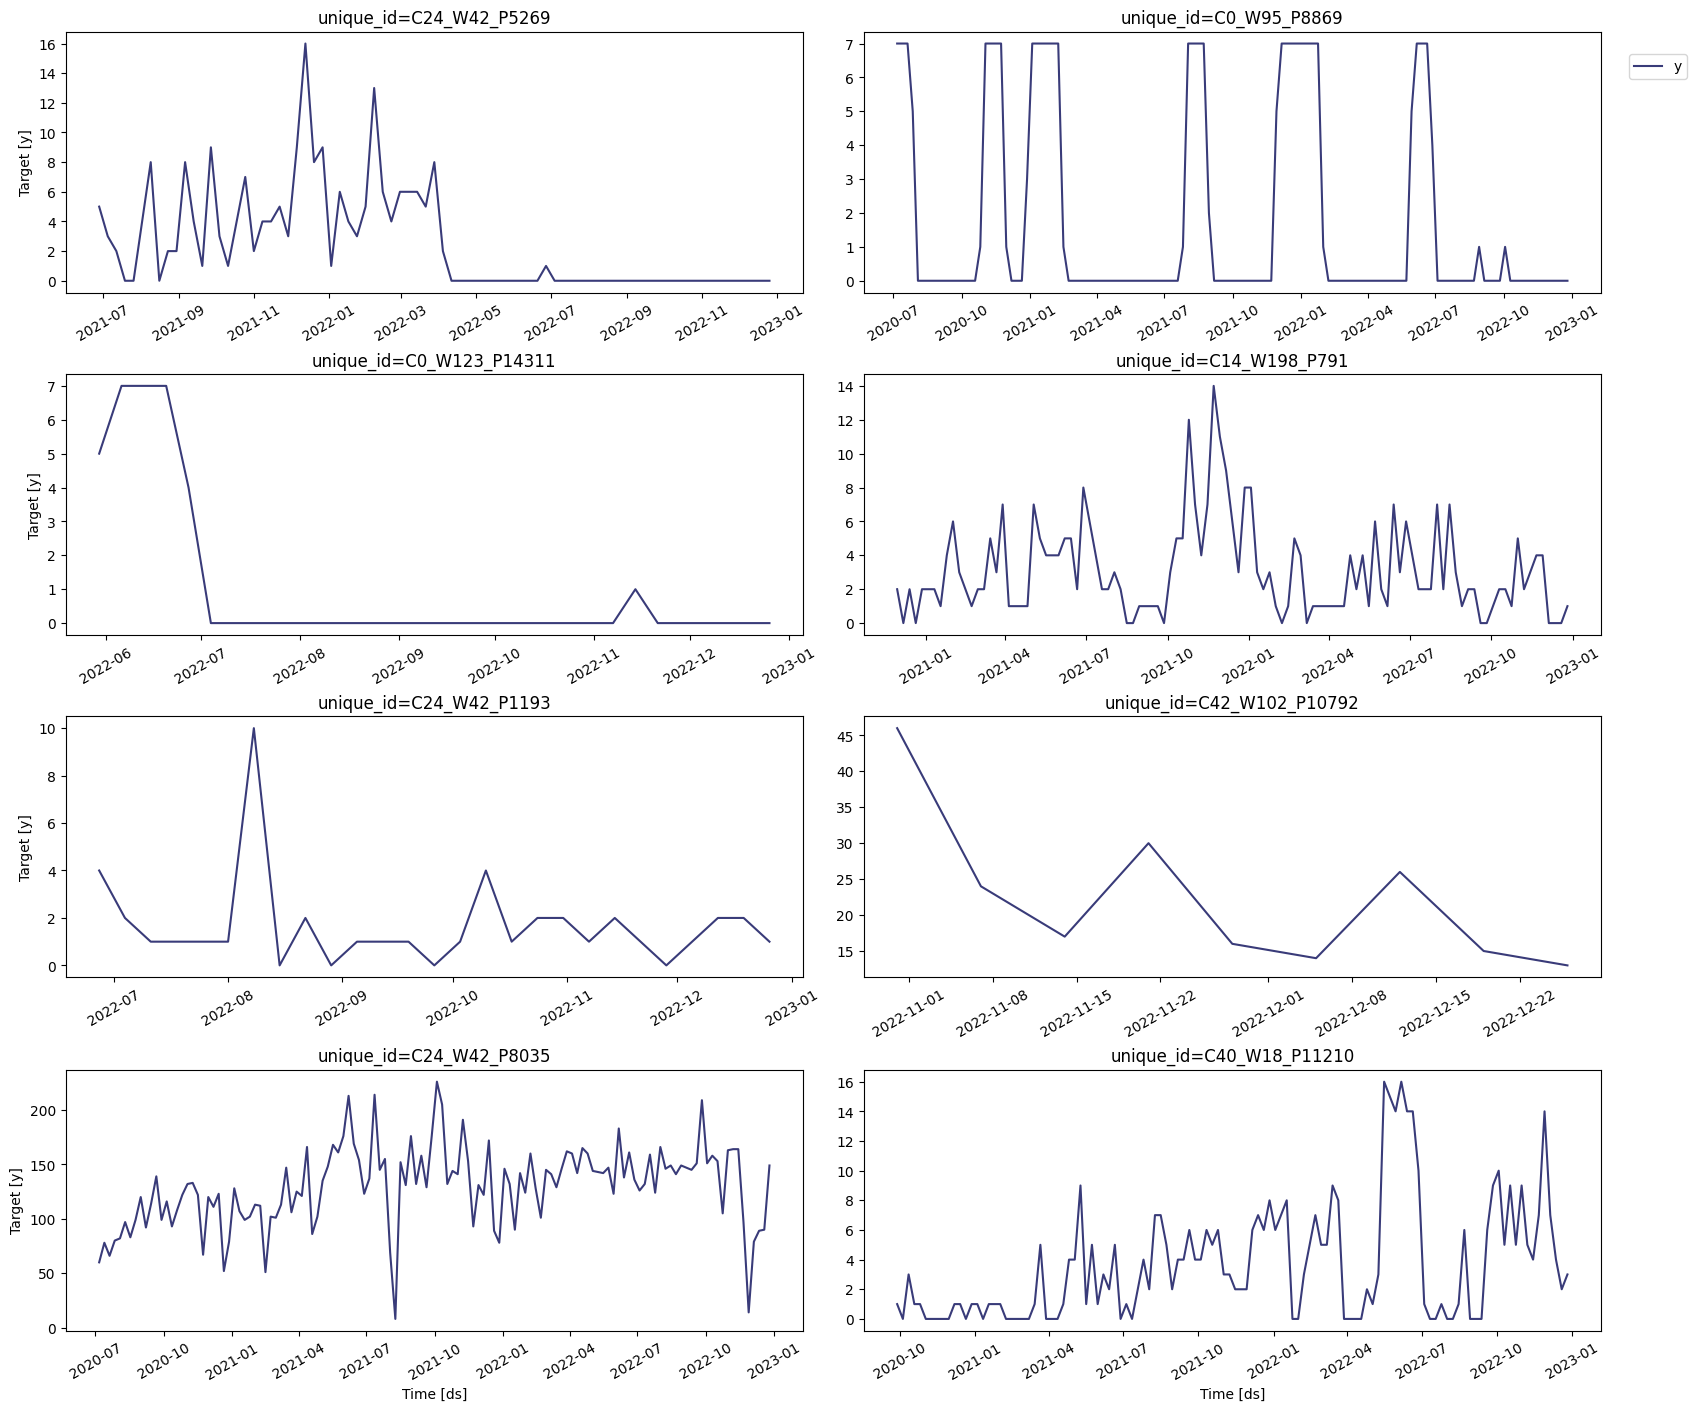

In [14]:
nixtla_client.plot(train, time_col='ds', target_col='y')

In [15]:
start = time.time()
timegpt_fcst_df = nixtla_client.forecast(df=train, h=horizon, time_col='ds', target_col='y', freq='W', model='timegpt-1-long-horizon')
timegpt_duration = time.time() - start
print("TimeGPT inference duration (seconds):", timegpt_duration)
timegpt_fcst_df.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


TimeGPT inference duration (seconds): 3.337883710861206


,unique_id,ds,TimeGPT
0,C0_W100_P10705,2023-01-01,1.106796
1,C0_W100_P10705,2023-01-08,1.333465
2,C0_W100_P10705,2023-01-15,1.259365
3,C0_W100_P10705,2023-01-22,1.053235
4,C0_W100_P10705,2023-01-29,0.861364


In [16]:
timegpt_fcst_df['ds'] = pd.to_datetime(timegpt_fcst_df['ds'])
timegpt_fcst_df['ds'] = timegpt_fcst_df['ds'] + pd.DateOffset(days=1)

In [17]:
timegpt_fcst_df.head()

,unique_id,ds,TimeGPT
0,C0_W100_P10705,2023-01-02,1.106796
1,C0_W100_P10705,2023-01-09,1.333465
2,C0_W100_P10705,2023-01-16,1.259365
3,C0_W100_P10705,2023-01-23,1.053235
4,C0_W100_P10705,2023-01-30,0.861364


# Evaluating Results

In [18]:
from functools import reduce

# Merge All Results
# data_frames = [mlforecast, chronos_df, timegpt_fcst_df, timesfm_df]
data_frames = [timegpt_fcst_df, timesfm_df]
final_forecast_weekly_merged = reduce(lambda  left,right: pd.merge(left,right,on=['unique_id', 'ds'],how='inner'), data_frames)
     


In [19]:
final_forecast_weekly_merged

,unique_id,ds,TimeGPT,timesfm,timesfm-q-0.1,timesfm-q-0.2,timesfm-q-0.3,timesfm-q-0.4,timesfm-q-0.5,timesfm-q-0.6,timesfm-q-0.7,timesfm-q-0.8,timesfm-q-0.9
0,C0_W100_P10705,2023-01-02,1.106796,2.248100,-0.218449,0.821319,1.466434,1.867880,2.248100,2.622732,3.153179,3.861244,4.806526
1,C0_W100_P10705,2023-01-09,1.333465,3.262197,0.071616,1.373737,2.195051,2.775104,3.262197,3.907597,4.471462,5.349155,6.592077
2,C0_W100_P10705,2023-01-16,1.259365,3.913786,0.158884,1.664117,2.557185,3.260320,3.913786,4.607748,5.298633,6.090182,7.469895
3,C0_W100_P10705,2023-01-23,1.053235,4.599056,0.538129,2.091623,3.130506,3.831812,4.599056,5.263231,6.012280,6.962626,8.150627
4,C0_W100_P10705,2023-01-30,0.861364,5.267920,0.704571,2.479102,3.589195,4.311939,5.267920,5.983479,6.856723,7.683194,8.979773
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013125,C9_W82_P9804,2024-08-19,0.042588,0.074069,-0.033751,0.005067,0.016404,0.040597,0.074069,0.107417,0.160561,0.256847,0.442951
1013126,C9_W82_P9804,2024-08-26,0.043832,0.065511,-0.042831,-0.007343,0.009644,0.033119,0.065511,0.109967,0.163702,0.258567,0.450375
1013127,C9_W82_P9804,2024-09-02,0.045704,0.069405,-0.034837,-0.005816,0.010999,0.041938,0.069405,0.111436,0.176554,0.264333,0.469028
1013128,C9_W82_P9804,2024-09-09,0.049736,0.084996,-0.030708,0.003850,0.024089,0.050444,0.084996,0.126834,0.195989,0.283398,0.492770


In [20]:
final_forecast_weekly_merged.to_csv("./data/final_forecast_weekly_merged.csv")


In [21]:
actuals=test
forecast=pd.read_csv("./data/final_forecast_weekly_merged.csv")

In [22]:
train["ds"]=pd.to_datetime(train["ds"])
actuals["ds"]=pd.to_datetime(actuals["ds"])
forecast["ds"]=pd.to_datetime(forecast["ds"])

In [23]:
def vn1_competition_evaluation(test, forecast, model):
    """
    Computes competition evaluation score: MAE% + |Bias%|
    """
   
    forecast['ds'] = pd.to_datetime(forecast['ds'])
    test['ds'] = pd.to_datetime(test['ds'])

    # Merge forecast with test data
    res = pd.merge(forecast, test, on=['unique_id', 'ds'], how='inner')
    
    # Calculate absolute error and error
    res['abs_err'] = abs(res[model] - res['y'])
    res['err'] = res[model] - res['y']
    
    # Calculate score: MAE% + |Bias%|
    abs_err = res['abs_err'].sum(skipna=True)
    err = res['err'].sum(skipna=True)
    score = (abs_err + abs(err)) / res['y'].sum()

    return round(score, 4)


In [24]:
def evaluate(train, actuals, forecast, seasonality=52, id_col='unique_id', target_col='y'):
    fcst_and_actuals = pd.merge(actuals, forecast, on=['ds', 'unique_id'], how='left')
    
    # Models to evaluate
    models = ["TimeGPT", "timesfm"]

    # Compute MASE and SMAPE 
    mase_val = mase(fcst_and_actuals, models=models, seasonality=seasonality,
                    train_df=train, id_col=id_col, target_col=target_col).mean(numeric_only=True)
    smape_val = smape(fcst_and_actuals, models=models, id_col=id_col, target_col=target_col).mean(numeric_only=True)

    # Compute VN1 score for each model
    vn1_scores = {model: vn1_competition_evaluation(actuals, forecast, model) for model in models}

    # Build results table
    results = pd.DataFrame({
        'mase': mase_val,
        'smape': smape_val,
        'score': pd.Series(vn1_scores)
    }, index=models)

    results.index.name = 'models'
    results = results.round(4)

    # Add inference durations if available
    inference_times = {
        'TimeGPT': timegpt_duration,
        'timesfm': timesfm_duration,
    }
    results["inference_time (s)"] = results.index.map(inference_times)

    return results


In [25]:
weekly_results=evaluate(train, actuals, forecast, seasonality=52, id_col='unique_id', target_col='y')

## RESULTS

In [26]:
weekly_results

,mase,smape,score,inference_time (s)
models,,,,
TimeGPT,1.0482,0.5431,0.6737,3.337884
timesfm,1.0670,0.5561,0.8017,6.585456


## VISUALIZATION

In [27]:
# Select a random unique_id from the forecast DataFrame
random_unique_id = random.choice(forecast['unique_id'].unique().tolist())


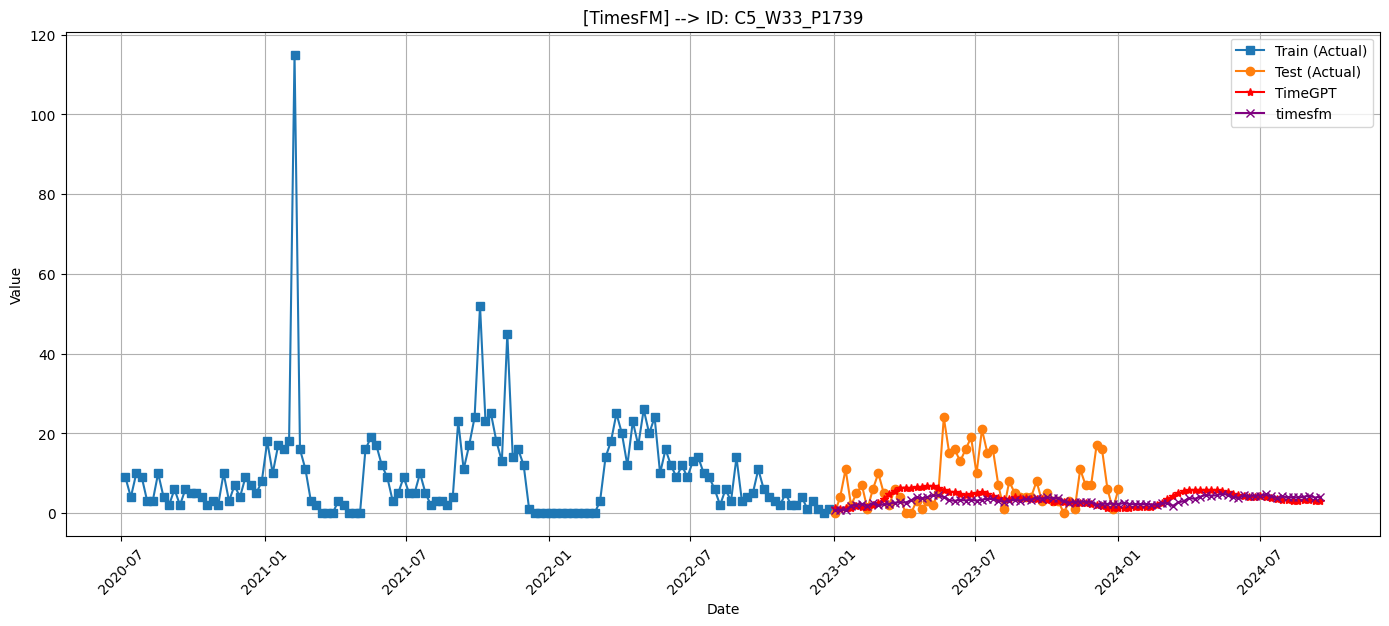

In [28]:
import random
import matplotlib.pyplot as plt


# Filter data for the selected random unique_id
target_id = random_unique_id
actuals_filtered = actuals[actuals['unique_id'] == target_id]
forecast_filtered = forecast[forecast['unique_id'] == target_id]
train_filtered = train[train['unique_id'] == target_id]

# Plotting all series together
plt.figure(figsize=(14, 6))
plt.plot(train_filtered['ds'], train_filtered['y'], label='Train (Actual)', marker='s')
plt.plot(actuals_filtered['ds'], actuals_filtered['y'], label='Test (Actual)', marker='o')
plt.plot(forecast_filtered['ds'], forecast_filtered['TimeGPT'], label='TimeGPT', color='red', marker='*')
plt.plot(forecast_filtered['ds'], forecast_filtered['timesfm'], label='timesfm', color='purple', marker='x')

plt.title(f"[TimesFM] --> ID: {target_id}")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()